In [3]:
import pandas as pd
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt

df = pd.read_csv("netflix_github_analysis_dataset.csv")



In [4]:
df.head(3)

,show_id,type,title,director,cast,country,language,date_added,release_year,rating,duration,runtime_minutes,listed_in,imdb_score,popularity_score,netflix_original,description
0,n00001,Movie,Stranger Things,Ryan Murphy,"Dev Patel, Regé-Jean Page, Florence Pugh",Japan,Japanese,24-09-2016,2009,TV-14,107 min,107.0,"Reality TV, Horror",8.1,75,False,"Stranger Things is a movie in the Reality TV, ..."
1,n00002,TV Show,Wednesday,Martin Scorsese,"Kiara Advani, Scarlett Johansson, Regé-Jean Page",France,French,28-01-2020,2020,TV-MA,3 Seasons,NaN,"Mystery, Action, Horror",8.3,86,False,"Wednesday is a tv show in the Mystery, Action,..."
2,n00003,Movie,Bridgerton,Alfonso Cuarón,"Millie Bobby Brown, Ryan Reynolds, Úrsula Corberó",Japan,Japanese,21-03-2018,2018,TV-MA,174 min,174.0,History,9.2,78,True,Bridgerton is a movie in the History category ...


In [5]:
df.tail(3)

,show_id,type,title,director,cast,country,language,date_added,release_year,rating,duration,runtime_minutes,listed_in,imdb_score,popularity_score,netflix_original,description
1997,n01998,TV Show,Alice in Borderland: Origins,Rian Johnson,"Rajkummar Rao, Claire Foy, Millie Bobby Brown",United States,Spanish,06-12-2017,2015,TV-MA,2 Seasons,NaN,Crime,6.8,85,True,Alice in Borderland: Origins is a tv show in t...
1998,n01999,TV Show,City of House 1999,Greta Gerwig,"Jenna Ortega, Kriti Sanon, Millie Bobby Brown",France,French,19-10-2023,2023,TV-PG,1 Season,NaN,"Animation, War",6.8,76,True,City of House 1999 is a tv show in the Animati...
1999,n02000,Movie,Extraction: Aftermath,Martin Scorsese,"Rajkummar Rao, Radhika Apte, Kiara Advani",India,Hindi,29-04-2019,2010,TV-PG,84 min,84.0,"Romance, History",7.0,76,True,Extraction: Aftermath is a movie in the Romanc...


In [6]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'language',
       'date_added', 'release_year', 'rating', 'duration', 'runtime_minutes',
       'listed_in', 'imdb_score', 'popularity_score', 'netflix_original',
       'description'],
      dtype='str')

In [7]:
#  QUESTION 1 - WHEATHER NETFLIX HAS MORE TV SHOWS OR MOVIES
# wheather it is a show or a movie is stored in type 
# so we count the type first to know how many movies and how many shows we have 
# then we build plot on ity 

In [8]:
type_counts = df['type'].value_counts()
type_counts

type
Movie      1355
TV Show     645
Name: count, dtype: int64

In [9]:
# lets calculate percentage to make analyzing stronger 

type_percentage = df['type'].value_counts(normalize=True)*100
type_percentage

type
Movie      67.75
TV Show    32.25
Name: proportion, dtype: float64

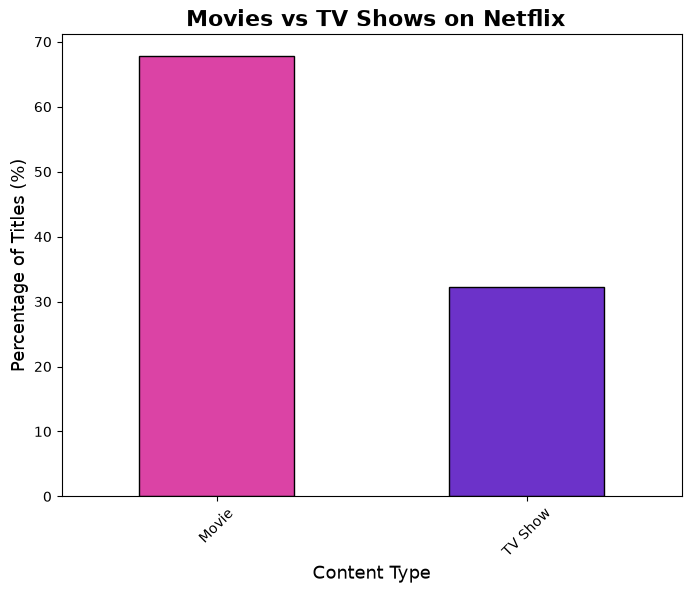

In [64]:
# plot the graph

type_percentage.plot(kind='bar' , color=["#DB43A5" ,"#6C32C9"] , figsize=(8,6) , edgecolor ='black' , legend=False)
plt.title(" Movies vs TV Shows on Netflix" , fontsize = 16 ,fontweight = 'bold' )
plt.xlabel("Content Type",fontsize =13)
plt.ylabel("Percentage of Titles (%)", fontsize=13)
plt.xticks(rotation =45)
plt.show()

In [26]:
# QUESTION 2 - WHICH GENRES ARE MOST POPULAR ON NETFLIX
# genres are in listed_in , first 
# count the values after splitting , exploding

In [27]:
df['listed_in'].head()

0         Reality TV, Horror
1    Mystery, Action, Horror
2                    History
3           Documentary, War
4                 War, Crime
Name: listed_in, dtype: str

In [28]:
genre  = df['listed_in'].explode()
genre

# here explode did not work because list only works on lists not plain strings . so first convert the listed_in to list.

0            Reality TV, Horror
1       Mystery, Action, Horror
2                       History
3              Documentary, War
4                    War, Crime
                 ...           
1995                    Fantasy
1996            Mystery, Comedy
1997                      Crime
1998             Animation, War
1999           Romance, History
Name: listed_in, Length: 2000, dtype: str

In [38]:
# to convert listed_in to list from string use   .str.spli(',') , explode() , .str.strip()

genres  = df['listed_in'].str.split(',').explode().str.strip()
genres

0       Reality TV
0           Horror
1          Mystery
1           Action
1           Horror
           ...    
1997         Crime
1998     Animation
1998           War
1999       Romance
1999       History
Name: listed_in, Length: 4026, dtype: str

In [56]:
genre_count  = genres.value_counts().head(10)
genre_count

listed_in
Drama          253
Action         239
Mystery        236
Crime          236
Documentary    227
Romance        227
Fantasy        226
Family         225
Horror         224
Reality TV     223
Name: count, dtype: int64

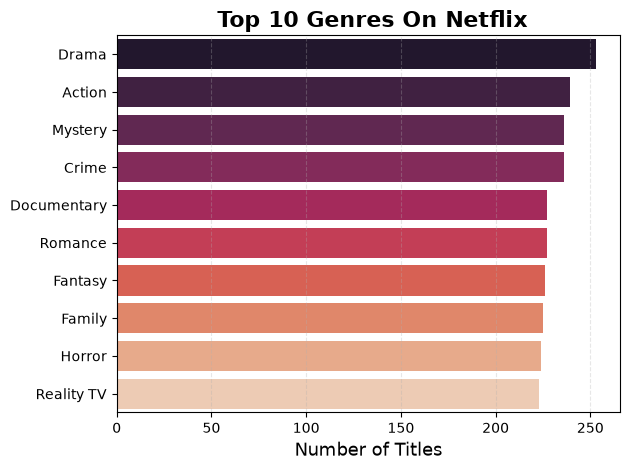

In [66]:
sns.barplot(x=genre_count.values , y=genre_count.index , legend=False , palette="rocket", hue=genre_count.index )
plt.title( " Top 10 Genres On Netflix" , fontsize = 16 , fontweight ='bold')
plt.xlabel("Number of Titles",fontsize = 13)
plt.ylabel("")
plt.grid(axis="x", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# QUESTION 3 - WHICH GENRES PERFORM BEST BY BOTH IMDB SCORE AND POPULARITY 
# genres are stored in listed_in 
# IMDB score - imdb_score
# popularrity - popularity_score 

In [79]:
# we create a same dataset 
genre_analysis = df.copy()

# make genres separate 

genre_analysis['listed_in'] = genre_analysis['listed_in'].str.split(',')
genre_analysis = genre_analysis.explode('listed_in')
genre_analysis['listed_in'] =genre_analysis['listed_in'].str.strip()

# now we groupby listed in that we get genre name then under it the show names

genre_analysis = genre_analysis.groupby('listed_in')
genre_analysis = genre_analysis.agg(
    title_count = ('title' , 'count')        # makes a new column on title aggregated count 
    avg_imdb_score = ('imdb_score' , 'mean')
     avg_popularity=('popularity_score', 'mean')
)

SyntaxError: invalid syntax. Perhaps you forgot a comma? (2013349719.py, line 14)